# k-nearest neighbors and Gaussian Naive Bayes

These are useful baselines because their assumptions are easy to state. kNN retains the training observations and uses local distances. Gaussian Naive Bayes replaces the observations with distributional summaries for each class.


## Data split and scaling

The data are divided into training, validation, and test partitions. The mean and standard deviation used for scaling are computed from the training partition only. The validation set selects `k`; the test set is kept for the final comparison.


In [1]:
import numpy as np

rng = np.random.default_rng(31)
n_per_class = 180
X0 = rng.normal(loc=(-1.0, -1.0), scale=0.8, size=(n_per_class, 2))
X1 = rng.normal(loc=(1.0, 1.0), scale=0.8, size=(n_per_class, 2))
X = np.vstack([X0, X1])
y = np.r_[np.zeros(n_per_class, dtype=int), np.ones(n_per_class, dtype=int)]
order = rng.permutation(len(y))
train, validation, test = order[:216], order[216:288], order[288:]
X_train_raw, X_val_raw, X_test_raw = X[train], X[validation], X[test]
y_train, y_val, y_test = y[train], y[validation], y[test]
mean, std = X_train_raw.mean(axis=0), X_train_raw.std(axis=0)
X_train = (X_train_raw - mean) / std
X_val = (X_val_raw - mean) / std
X_test = (X_test_raw - mean) / std
print('split sizes:', len(X_train), len(X_val), len(X_test))


split sizes: 216 72 72


## k-nearest neighbors

For a query point, kNN finds the `k` closest training points and predicts their majority class. Small values of `k` can follow local noise. Larger values smooth the decision boundary. Since distance is central to the model, changing feature scale changes the result.


In [2]:
def knn_predict(X_train, y_train, X_query, k=5):
    predictions = []
    for point in X_query:
        distances = np.sum((X_train - point) ** 2, axis=1)
        nearest = np.argsort(distances)[:k]
        labels, counts = np.unique(y_train[nearest], return_counts=True)
        predictions.append(labels[np.argmax(counts)])
    return np.array(predictions)

candidate_k = [1, 3, 5, 11, 21]
validation_accuracy = []
for k in candidate_k:
    prediction = knn_predict(X_train, y_train, X_val, k=k)
    validation_accuracy.append(np.mean(prediction == y_val))
best_k = candidate_k[int(np.argmax(validation_accuracy))]
knn_test = knn_predict(X_train, y_train, X_test, k=best_k)
print('validation accuracy by k:', dict(zip(candidate_k, np.round(validation_accuracy, 3))))
print(f'selected k={best_k}; test accuracy={np.mean(knn_test == y_test):.3f}')


validation accuracy by k: {1: np.float64(0.986), 3: np.float64(0.986), 5: np.float64(0.972), 11: np.float64(0.986), 21: np.float64(0.986)}
selected k=1; test accuracy=0.903


## Choosing `k`

The notebook evaluates several candidate values on validation data and uses the best one for the final test prediction. This keeps the test set from becoming another tuning set.


## Gaussian Naive Bayes

For each class and feature, the model estimates a prior, a mean, and a variance. Prediction adds the log prior to the Gaussian log likelihood of each feature. The conditional-independence assumption is generally imperfect, but the approximation can still produce a useful classifier.


Gaussian Naive Bayes test accuracy: 0.944


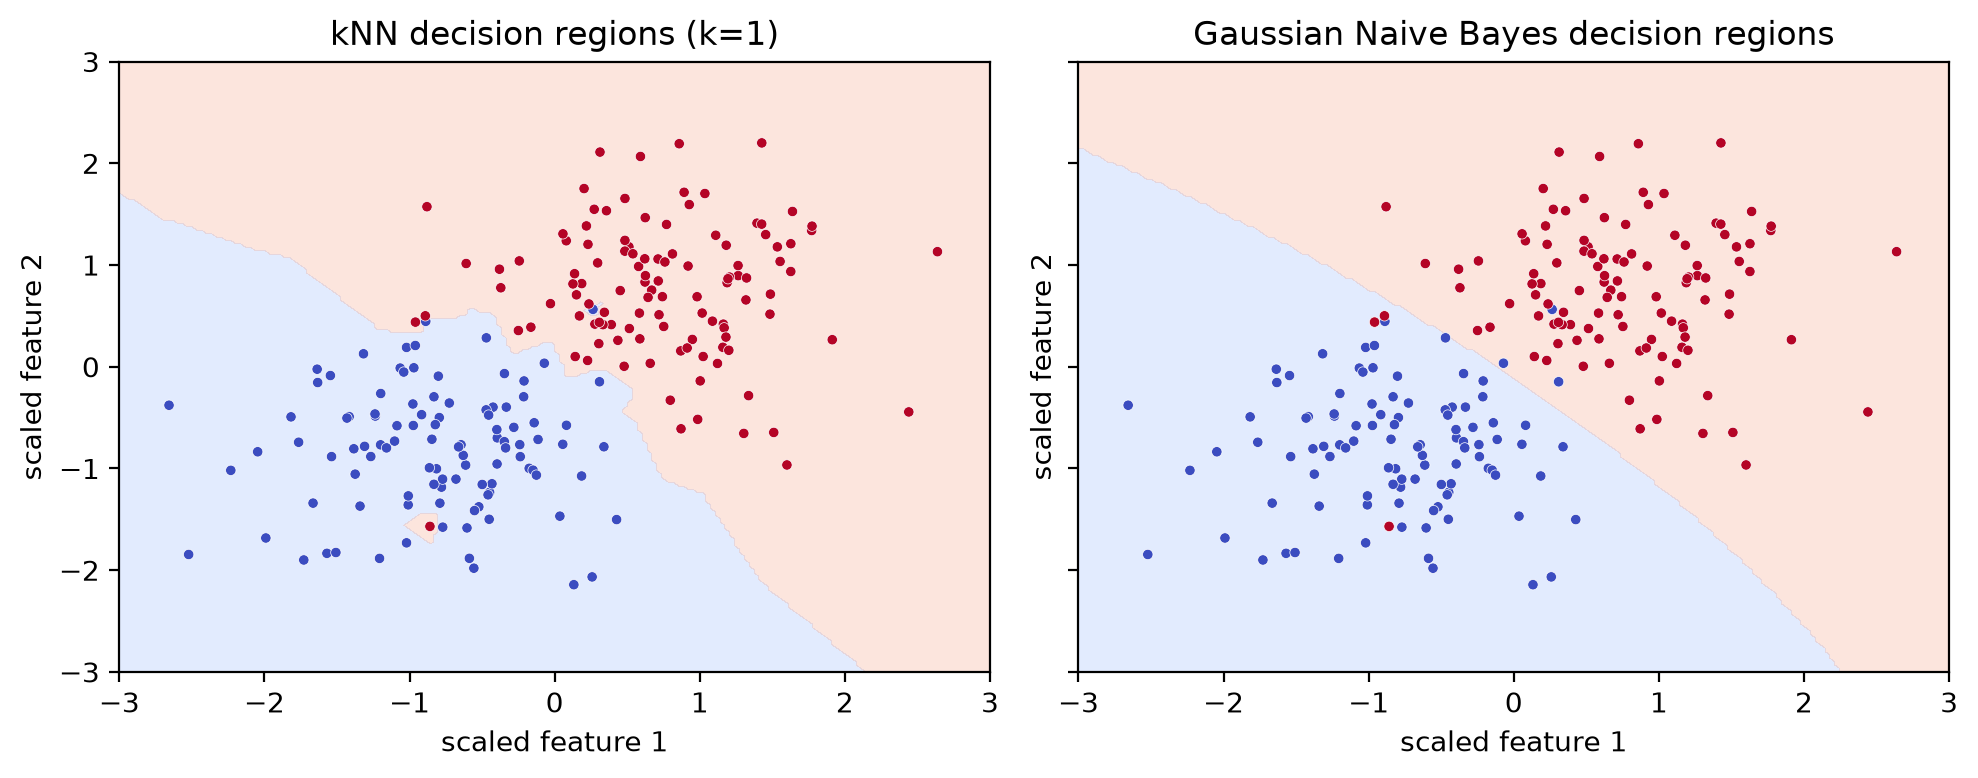

In [3]:
def fit_gaussian_nb(X, y):
    stats = {}
    for cls in np.unique(y):
        X_cls = X[y == cls]
        stats[cls] = {'prior': len(X_cls) / len(X), 'mean': X_cls.mean(axis=0), 'var': X_cls.var(axis=0) + 1e-8}
    return stats

def gaussian_log_likelihood(X, mean, var):
    return -0.5 * np.sum(np.log(2 * np.pi * var) + (X - mean) ** 2 / var, axis=1)

def gaussian_nb_predict(X, stats):
    classes = np.array(sorted(stats))
    scores = [np.log(stats[cls]['prior']) + gaussian_log_likelihood(X, stats[cls]['mean'], stats[cls]['var']) for cls in classes]
    return classes[np.argmax(np.vstack(scores), axis=0)]

stats = fit_gaussian_nb(X_train, y_train)
nb_test = gaussian_nb_predict(X_test, stats)
print(f'Gaussian Naive Bayes test accuracy: {np.mean(nb_test == y_test):.3f}')

import matplotlib.pyplot as plt
grid_1, grid_2 = np.meshgrid(np.linspace(-3, 3, 180), np.linspace(-3, 3, 180))
grid = np.c_[grid_1.ravel(), grid_2.ravel()]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, title, prediction in [(axes[0], f'kNN decision regions (k={best_k})', knn_predict(X_train, y_train, grid, best_k)), (axes[1], 'Gaussian Naive Bayes decision regions', gaussian_nb_predict(grid, stats))]:
    ax.contourf(grid_1, grid_2, prediction.reshape(grid_1.shape), levels=[-0.5, 0.5, 1.5], cmap='coolwarm', alpha=0.25)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', s=14, edgecolor='white', linewidth=0.25)
    ax.set(title=title, xlabel='scaled feature 1', ylabel='scaled feature 2')
fig.tight_layout()
plt.show()


## Decision regions

The two plots show the assumptions directly. kNN follows the arrangement of nearby training points, while Gaussian Naive Bayes produces a boundary based on the class-level means and variances. Similar accuracy would not make these models interchangeable: their storage and prediction costs are also different.
